In [21]:
import hoomd
import gsd.hoomd
import itertools
import math
import numpy

import freud

import matplotlib

%matplotlib inline
matplotlib.style.use("ggplot")
import matplotlib_inline

matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

In [22]:
cpu = hoomd.device.CPU()
#gpu = hoomd.device.GPU()

simulation = hoomd.Simulation(device=cpu)

print(simulation.state) #newly constructed simulation object has no state

#newly constructed simulation object also has no integrators, updaters, writers which are types of operators
print(simulation.operations.integrator) 

print(simulation.operations.updaters[:])

print(simulation.operations.writers[:])


None
None
[]
[]


Hard Particle Simulations: A hard particle Monte Carlo (HPMC) simulation represents particles as extended objects that are not allowed to overlap. There are no attractive or repulsive forces in the system. The shape of the particle alone controls how it interacts with other particles. Formally, the potential energy of the system is zero when there are no overlaps and infinite when there are. Purely hard interactions induce effective attractions between particles which can lead to ordered structures.

In [3]:
mc = hoomd.hpmc.integrate.ConvexPolyhedron() #complex polyhedron integrater

mc.shape["octahedron"] = dict( #shape of the polyhedron
    vertices=[ #six verticies for the octahedron 
        (-0.5, 0, 0),
        (0.5, 0, 0),
        (0, -0.5, 0),
        (0, 0.5, 0),
        (0, 0, -0.5),
        (0, 0, 0.5),
    ]
)

#Any trial move whose shape overlaps with another particle is rejected, leaving the particle’s position and orientation unchanged. Any trial move whose shape does not overlap with any other particle is accepted, setting the particle’s position or orientation to the new value.
mc.nselect = 2 #number of trial moves on each particle in each time step
mc.d["octahedron"] = 0.15 #translation move, Moves particle a random distance up to d
mc.a["octahedron"] = 0.2 #rotation move, Rotates particle at random angle. Higher, a, means larger possible rotation moves

simulation = hoomd.Simulation(device=cpu, seed=1)

#The seed value (passed to the simulation constructor above) selects the sequence of values in the pseudorandom number stream. Given the same initial condition and seed, HPMC simulations will produce exactly the same results.

simulation.operations.integrator = mc #there can only be one integrater in a simulation and it operates on the system state on every time step

In [4]:
#valid particle configurations have no overlaps in hard particle monte-carlo

m = 4 #any integer
N_particles = 2 * m**3 #number of particles following the bcc structure 

spacing = 1.2 #spacing slightly larger then the diameter of the sphere the encompasses the octahedron
K = math.ceil(N_particles ** (1 / 3)) #rounds the number up to the nearest integrer. Ordered arangment of particles. 
L = K * spacing #length of the range of particle placements inside a KxKxK cubic lattice. Size of the simulation box

#placing particles inside a cubic box
x = numpy.linspace(-L / 2, L / 2, K, endpoint=False) #particle spacing 
position = list(itertools.product(x, repeat=3)) #positions particles in a 3D lattices through iterative for-loop with cartisian product. Pairing every element with first set of each element of second set. Does this three time for three dimensions.
print(position[0:4])

#filter down to N particles because the boundary size is greater then or equal to number of particles depending on the spacing.
position = position[0:N_particles]

#setting the orientation of each particle using quaternion
orientation = [(1, 0, 0, 0)] * N_particles #this quaternion represents no rotation


[(np.float64(-3.5999999999999996), np.float64(-3.5999999999999996), np.float64(-3.5999999999999996)), (np.float64(-3.5999999999999996), np.float64(-3.5999999999999996), np.float64(-2.3999999999999995)), (np.float64(-3.5999999999999996), np.float64(-3.5999999999999996), np.float64(-1.1999999999999997)), (np.float64(-3.5999999999999996), np.float64(-3.5999999999999996), np.float64(0.0))]


In [5]:
frame = gsd.hoomd.Frame() #initializing state
frame.particles.N = N_particles 
frame.particles.position = position
frame.particles.orientation = orientation

frame.particles.typeid = [0] * N_particles #each particle has the same type id
frame.particles.types = ["octahedron"]
frame.configuration.box = [L, L, L, 0, 0, 0] #here is the simulation/configuration box. Represented in six element array, including tilt

with gsd.hoomd.open(name="lattice.gsd", mode="x") as f:
    f.append(frame)
    
simulation.create_state_from_gsd(filename="lattice.gsd") #writing to a GSD File

In [6]:
#sames snapshot of the original simulation to see how far particles are moved throughout the simulation
initial_snapshot = simulation.state.get_snapshot()

#runs the simulation. 10,000 steps is enough to randomize a low density simulation 
simulation.run(10e3) #randomizes by running the simulation


In [7]:
#Recieves a final snapshot to compare how the particles have moved through the simulation
final_snapshot = simulation.state.get_snapshot()

print("initial snapshot of particles position and then orientation")
initial_snapshot.particles.position[0:4]
initial_snapshot.particles.orientation[0:4]

print("snapshot of particles position after simulation and then orientation")
final_snapshot.particles.position[0:4]
final_snapshot.particles.orientation[0:4]




initial snapshot of particles position and then orientation
snapshot of particles position after simulation and then orientation


array([[ 0.60618387, -0.38879777,  0.0507035 ,  0.6919585 ],
       [-0.0913863 , -0.52134195,  0.14489461, -0.83597647],
       [-0.03713859,  0.77644024,  0.51407427, -0.36261403],
       [ 0.32967127, -0.85460617, -0.38397494, -0.1163116 ]])

In [8]:
#You can quary properties of the HPMC integrator to see what it did 

mc.translate_moves #this querys a touple of the number of accepted vs the number of rejected translation moves
mc.rotate_moves #this querys a tuple of the number of accepted vs the number of rejected rotation moves
mc.overlaps #this will be zero for the final configuration because all overlaps are rejected

print(mc.translate_moves[0]/sum(mc.translate_moves)) #this ratio of accepted vs total mvoes is high for low density because much less overlaps. Same for rotations


0.9156171491308611


In [9]:
#save the final configuration to a GSD file
hoomd.write.GSD.write(state=simulation.state, mode="xb", filename="random.gsd")

Compressing The System

In [10]:
cpu = hoomd.device.CPU()
simulation = hoomd.Simulation(device=cpu, seed=12)
simulation.create_state_from_gsd(filename="random.gsd") #initializes the state

#computing the volume of the octahedron
a = math.sqrt(2) / 2 #edges in the octahedron. Distance between the verticies using trig 
V_particle = 1 / 3 * math.sqrt(2) * a**3 #volume of formulat for octahedron 

#volume fraction. Ratio of the volume occupied by the particles to the volume of the periodic box. Self assembly typically occurs with a volume fraction above 0.5 
initial_volume_fraction = (
    simulation.state.N_particles * V_particle / simulation.state.box.volume
)
print(initial_volume_fraction)

0.05715592589579699


In [11]:
mc = hoomd.hpmc.integrate.ConvexPolyhedron()
mc.shape["octahedron"] = dict(
    vertices=[
        (-0.5, 0, 0),
        (0.5, 0, 0),
        (0, -0.5, 0),
        (0, 0.5, 0),
        (0, 0, -0.5),
        (0, 0, 0.5),
    ]
)
simulation.operations.integrator = mc

An Updater is a type of operation in HOOMD-blue that makes changes to the state. To use an Updater, first instantiate the object, assign a Trigger, and add it to the Simulation. Simulation will apply the Updater on time steps where the Trigger returns True. The Periodic trigger returns True every period steps.

QuickCompress is an Updater that works with HPMC to quickly compress the box to a target volume. When triggered, QuickCompress reduces the box volume by a scale factor, while allowing slight overlaps between the particles. It then waits for the translation and rotation trial moves to remove these overlaps before it reduces the volume again. This process temporarily produces invalid system configurations, but is much quicker than a process that does not allow temporary overlaps.

Compute the final box size with a volume fraction above 0.5 and configure a QuickCompress to trigger every 10 time steps.

In [12]:
#UPDATER Quick Compress => Compresses box to target volume ratio

initial_box = simulation.state.box #query your initial box
final_box = hoomd.Box.from_box(initial_box) #set your final box
final_volume_fraction = 0.57 #set your volume fraction 
final_box.volume = simulation.state.N_particles * V_particle / final_volume_fraction #set your final box volumne
compress = hoomd.hpmc.update.QuickCompress( #apply quick compress
    trigger=hoomd.trigger.Periodic(10), target_box=final_box #allows for invalid configurations but is much quicker then not
)

simulation.operations.updaters.append(compress) #adds the quick compress updater to the simulation 

A Tuner is another type of operation. Tuners make changes to other operations to improve performance. In HPMC, the translation and rotation trial move sizes have a huge performance impact. When the move size is too small it takes many time steps to make appreciable changes to the system. When the move size is too large very few moves are accepted and it again takes many time steps to make appreciable changes. The system makes the most progress at moderate move sizes and, in most cases, the optimal acceptance ratio is 20%. The MoveSize tuner monitors the acceptance ratio and adjusts d and a to achieve the target.

The optimal move size depends on the density of the system. QuickCompress changes the density rapidly during compression, so use the MoveSize tuner to adjust the move sizes regularly:

In [13]:
#MoveSize Tuner

periodic = hoomd.trigger.Periodic(10) #trigger every 10 time steps
tune = hoomd.hpmc.tune.MoveSize.scale_solver(
    moves=["a", "d"], #adjust a and d. To see the final move size you can look at it by mc.a['octahedron'] or mc.d['octahedron']
    target=0.2,
    trigger=periodic,
    max_translation_move=0.2,
    max_rotation_move=0.2,
)
simulation.operations.tuners.append(tune) #add to the simulation 

In [14]:
while not compress.complete and simulation.timestep < 1e6: #stops the simulation when the compression is complete or when the timestep exceeds a certain value here (1e6)
    simulation.run(1000)

if not compress.complete: #checking if previous while loop excited because of the timestep
    message = "Compression failed to complete"
    raise RuntimeError(message)

In [15]:
hoomd.write.GSD.write(state=simulation.state, mode="xb", filename="compressed.gsd")

So far, this tutorial has placed N non-overlapping octahedra randomly in a box and then compressed it to a moderate volume fraction. The resulting configuration of particles is valid, but strongly dependent on the path taken to create it. There are many more equilibrium configurations in the set of possible configurations that do not depend on the path. Equilibrating the system is the process of taking an artificially prepared state and running a simulation. During the simulation run, the system will relax to equilibrium. 

In [16]:
#Equillibrium is the process of taking an artifically prepared state and running a simulation during which the sysetem will relax to equilibrium independent of the path taken.
cpu = hoomd.device.CPU()
simulation = hoomd.Simulation(device=cpu, seed=12)
mc = hoomd.hpmc.integrate.ConvexPolyhedron()
mc.shape["octahedron"] = dict(
    vertices=[
        (-0.5, 0, 0),
        (0.5, 0, 0),
        (0, -0.5, 0),
        (0, 0.5, 0),
        (0, 0, -0.5),
        (0, 0, 0.5),
    ]
)
simulation.operations.integrator = mc

simulation.create_state_from_gsd(filename="compressed.gsd")

logger = hoomd.logging.Logger()
logger.add(mc, quantities=["type_shapes"])

gsd_writer = hoomd.write.GSD( #saves trajectories not just the final state. Allows to visualize the process towrad equillibrium
    filename="trajectory.gsd", trigger=hoomd.trigger.Periodic(1000), mode="xb", filter=hoomd.filter.All(), logger=logger
)
simulation.operations.writers.append(gsd_writer)


#adding a tuner 
#Trigger the tuner every 100 steps but only for the first 5000 steps of the simulation by combining a Periodic and Before trigger with an And operation. Before returns True for all time steps t < value and the And trigger returns True when all of its child triggers also return True.
tune = hoomd.hpmc.tune.MoveSize.scale_solver(
    moves=["a", "d"],
    target=0.2, #target acceptance ratio of the tuner which is checked in the next cell
    trigger=hoomd.trigger.And(
        [hoomd.trigger.Periodic(100), hoomd.trigger.Before(simulation.timestep + 5000)]
    ),
)
simulation.operations.tuners.append(tune)
simulation.run(5000)

In [17]:
#verifying the the tuner achieved the target acceptance ratios by running the next 100 time steps

simulation.run(100)

rotate_moves = mc.rotate_moves
mc.rotate_moves[0] / sum(mc.rotate_moves)

translate_moves = mc.translate_moves
mc.translate_moves[0] / sum(mc.translate_moves)

0.2088083710760581

To equilibrate the system, run the simulation. The length of the run needed is strongly dependent on the particular model, the system size, the density, and many other factors. Hard particle Monte Carlo self-assembly often takes tens of millions of time steps for systems with ~10,000 particles. This system is much smaller, so it takes fewer steps.

In [18]:
simulation.run(2e5)
hoomd.write.GSD.write(state=simulation.state, mode="xb", filename="equilibrium.gsd", logger=logger) #may want to see the trajectories here too in which case use the code from ONQ
gsd_writer.flush()

Equilibration Challenges

In the previous section, you ran the hard octahedra system for many time steps to equilibrate it and saved the trajectory in trajectory.gsd. Is the final state you obtained actually an equilibrium state? Statistical mechanics tells us that as long as our system is ergodic it will eventually achieve equilibrium. You need to analyze this trajectory to determine if you have achieved the ordered equilibrium structure.

MUST ANALYZE THE TRAJECTORY TO DETERMINE IF EQUILIBRIUM WAS ACHIEVED

In [19]:
traj = gsd.hoomd.open("trajectory.gsd")

len(traj) #amount of frames

205

A system is ergodic when it can explore all possible states by making small moves from one to another. In HPMC simulations, low volume fraction simulations are ergodic while very high volume fraction ones are not. At high volume fractions, there isn’t enough free space for the particles to rearrange so they get stuck in local configurations.

Visualize the motion of just a few particles to see if they appear stuck or if they are freely moving about the box. Use OVITO

Good! Over the first part of the simulation (while the system is still fluid), individual particles are able to translate a moderate distance and explore many different orientations. This indicates that our system is ergodic, but does not prove it.

Simulation Length
How can you tell if you have run long enough to equilibrate the system? The hard octahedra system forms the bcc structure by nucleation and growth. Nucleation is a rare event, so you need to keep running the simulation until it occurs. If you ran this simulation many times with different random seeds, each would take a different number of steps to nucleate. You need to examine the simulation trajectory in detail to determine if you have run it long enough.


Can you see the system ordering? The orientations of the octahedra appear to quickly snap to face the same direction and the particle positions line up on evenly spaced planes. You can use freud’s SolidLiquid analysis method to quantitatively identify which particles are in the solid structure.

Loop over all of the frames in the file and create a boolean array that indicates which particles are in a solid environment:

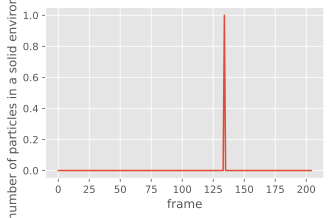

In [20]:
solid = freud.order.SolidLiquid(l=6, q_threshold=0.7, solid_threshold=6)
is_solid = []
for frame in traj:
    solid.compute(
        system=(frame.configuration.box, frame.particles.position),
        neighbors=dict(mode="nearest", num_neighbors=8),
    )
    is_solid.append(solid.num_connections > solid.solid_threshold)
    
fig = matplotlib.figure.Figure(figsize=(5, 3.09))
ax = fig.add_subplot()
num_solid = numpy.array([numpy.sum(a) for a in is_solid])
ax.plot(num_solid)
ax.set_xlabel("frame")
ax.set_ylabel("number of particles in a solid environment")
fig #identifies the amount of particles that are in a solid structure

This plot confirms what you saw visually and what you should expect in a system that nucleates and grows a crystal. There is no solid at the beginning of the simulation. Then a solid cluster forms and grows to fill the box.

Visualize just the solid particles to see this more clearly:

In [ ]:
#Equillibrium is the process of taking an artifically prepared state and running a simulation during which the sysetem will relax to equilibrium independent of the path taken.\
cpu = hoomd.device.CPU()
simulation = hoomd.Simulation(device=cpu, seed=12)
mc = hoomd.hpmc.integrate.ConvexPolyhedron()
mc.shape["octahedron"] = dict(
    vertices=[
        (-0.5, 0, 0),
        (0.5, 0, 0),
        (0, -0.5, 0),
        (0, 0.5, 0),
        (0, 0, -0.5),
        (0, 0, 0.5),
    ]
)
simulation.operations.integrator = mc

simulation.create_state_from_gsd(filename="compressed.gsd")

logger = hoomd.logging.Logger()
logger.add(mc, quantities=["type_shapes"])

gsd_writer = hoomd.write.GSD( #saves trajectories not just the final state. Allows to visualize the process towrad equillibrium
    filename="trajectory2.gsd", trigger=hoomd.trigger.Periodic(1000), mode="xb", filter=hoomd.filter.All(), logger=logger
)
simulation.operations.writers.append(gsd_writer)


#adding a tuner 
#Trigger the tuner every 100 steps but only for the first 5000 steps of the simulation by combining a Periodic and Before trigger with an And operation. Before returns True for all time steps t < value and the And trigger returns True when all of its child triggers also return True.
tune = hoomd.hpmc.tune.MoveSize.scale_solver(
    moves=["a", "d"],
    target=0.2, #target acceptance ratio of the tuner which is checked in the next cell
    trigger=hoomd.trigger.And(
        [hoomd.trigger.Periodic(100), hoomd.trigger.Before(simulation.timestep + 5000)]
    ),
)
simulation.operations.tuners.append(tune)
simulation.run(2e5)

In [ ]:
simulation.run(2e5)
hoomd.write.GSD.write(state=simulation.state, mode="xb", filename="equilibrium2.gsd", logger=logger) #may want to see the trajectories here too in which case use the code from ONQ
gsd_writer.flush()